In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
# Load the dataset
path = "/Users/deepakshah/Downloads/DTDC.csv"
# Read the CSV file into a DataFrame
df= pd.read_csv(path)
df

,Origin,Destination,Pouch No,Date,Sender's Name,Sender Phone,Sender Address,Sender City,Sender State,Sender Pincode,...,Company Stamp,Receiver Signature,Receive Date,Tariff,VAS Charges,Total Amount,Mode,Risk Surcharge,Mode of Payment,Nature of Consignment
0,Nagpur,Jamshedpur,55e275ad-8da9-49c9-986c-93134fef2c19,6/25/2025,Megha Majumdar,6137840452,"H.No. 425 Varughese Chowk, Above Shop, Nagpur,...",Nagpur,Maharashtra,264582,...,NaN,NaN,6/30/2025,147.22,70.09,217.31,Express,Carrier,Cash,Dox
1,Jaipur,Vizag,7fab4175-11b2-4090-a0ed-4571ccd68878,6/27/2025,Nanda-Saraf,52907142,"48/880, Tripathi, Above Shop, Jaipur, Rajastha...",Jaipur,Rajasthan,200155,...,NaN,NaN,6/28/2025,256.83,82.20,339.03,Surface,Carrier,Card,Dox
2,Lucknow,Bhubaneswar,5231428d-b524-433e-8043-45c7e39a94aa,6/27/2025,Contractor LLC,5081512738,"257, Kulkarni Path, Above Shop, Lucknow, Uttar...",Lucknow,Uttar Pradesh,353311,...,NaN,NaN,6/28/2025,432.45,107.63,540.08,Surface,Carrier,Cash,Non-Dox
3,Coimbatore,Mumbai,2f556b38-298d-4e8c-9310-4e6a3a5fbe61,6/11/2025,Krishna Hans,1518559754,"83/17 Sridhar Zila, Above Shop, Coimbatore, Ta...",Coimbatore,Tamil Nadu,553663,...,NaN,NaN,6/15/2025,1162.00,25.23,1187.23,Express,Carrier,Card,Non-Dox
4,Meerut,Vijayawada,c3154041-34eb-435e-94d8-0900e6a9ed01,7/1/2025,Kuruvilla-Tiwari,1666398391,"16/64 Jayaraman Circle, Above Shop, Meerut, Ut...",Meerut,Uttar Pradesh,273143,...,NaN,NaN,7/5/2025,285.55,67.70,353.25,Surface,Carrier,Cash,Dox
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49634,Varanasi,Bhopal,78ad9246-96ca-40e0-a77e-1f5f601b2114,7/4/2025,Chavvi Kashyap,6657295176,"H.No. 66, Chaudry Marg, Behind School, Varanas...",Varanasi,Uttar Pradesh,864652,...,NaN,NaN,7/5/2025,485.50,31.14,516.64,Surface,Carrier,Card,Non-Dox
49635,Patna,Jamshedpur,be889bde-61ea-460c-8dc8-6bdaf7a91579,6/15/2025,"Chakrabarti, Pandit and Agrawal",5273847382,"62 Palla, Opposite Mall, Patna, Bihar - 114677",Patna,Bihar,114677,...,NaN,NaN,6/18/2025,451.46,124.68,576.14,Surface,Carrier,Cash,Dox
49636,Kolkata,Aurangabad,17a77c5d-ccdf-42c1-adc0-ec5b89b84154,6/6/2025,Arya Shere,4416278858,"H.No. 959, Shetty Ganj, Opposite Mall, Kolkata...",Kolkata,West Bengal,19999,...,NaN,NaN,6/8/2025,458.24,63.33,521.57,Surface,Carrier,Cash,Dox
49637,Srinagar,Aurangabad,9eae5dad-b5c0-4047-b1fe-a340dbc4e41e,7/5/2025,Harita Dhaliwal,5568995605,"960, Saini Street, Behind School, Srinagar, Ja...",Srinagar,Jammu & Kashmir,138785,...,Yes,Yes,7/10/2025,515.65,0.00,515.65,Air Cargo,Carrier,Wallet,Non-Dox


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49639 entries, 0 to 49638
Data columns (total 42 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Origin                 49639 non-null  object 
 1   Destination            49639 non-null  object 
 2   Pouch No               49639 non-null  object 
 3   Date                   49639 non-null  object 
 4   Sender's Name          49639 non-null  object 
 5   Sender Phone           49639 non-null  int64  
 6   Sender Address         49639 non-null  object 
 7   Sender City            49639 non-null  object 
 8   Sender State           49639 non-null  object 
 9   Sender Pincode         49639 non-null  int64  
 10  Sender GSTIN           26778 non-null  object 
 11  Total Pieces           49639 non-null  int64  
 12  Actual Wt              49639 non-null  float64
 13  Volumetric Wt          49639 non-null  float64
 14  Chargeable Wt          49639 non-null  float64
 15  Pa

In [5]:
df.isnull().sum()

Origin                       0
Destination                  0
Pouch No                     0
Date                         0
Sender's Name                0
Sender Phone                 0
Sender Address               0
Sender City                  0
Sender State                 0
Sender Pincode               0
Sender GSTIN             22861
Total Pieces                 0
Actual Wt                    0
Volumetric Wt                0
Chargeable Wt                0
Paperwork                    0
Sender Signature         19828
Sender Date                  0
Recipient Name               0
Recipient Phone              0
Recipient Address            0
Recipient City               0
Receiver State               0
Receiver Pincode             0
Description                  0
Value Added Services     10240
Consignment No               0
Expiry Date                  0
Booking Code                 0
Recipient GSTIN          35773
Receiver Name                0
Relationship                 0
Company 

In [6]:
df.shape


(49639, 42)

In [7]:
# Checking if there is any duplicate value
df.duplicated().sum()


0

In [8]:
 # Converting the columns which has null values from object to integer and filling null values with 0. 
df['Sender GSTIN'] = pd.to_numeric(df['Sender GSTIN'], errors='coerce').fillna(0).astype(int)
df['Sender Signature'] = pd.to_numeric(df['Sender Signature'], errors='coerce').fillna(0).astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49639 entries, 0 to 49638
Data columns (total 42 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Origin                 49639 non-null  object 
 1   Destination            49639 non-null  object 
 2   Pouch No               49639 non-null  object 
 3   Date                   49639 non-null  object 
 4   Sender's Name          49639 non-null  object 
 5   Sender Phone           49639 non-null  int64  
 6   Sender Address         49639 non-null  object 
 7   Sender City            49639 non-null  object 
 8   Sender State           49639 non-null  object 
 9   Sender Pincode         49639 non-null  int64  
 10  Sender GSTIN           49639 non-null  int64  
 11  Total Pieces           49639 non-null  int64  
 12  Actual Wt              49639 non-null  float64
 13  Volumetric Wt          49639 non-null  float64
 14  Chargeable Wt          49639 non-null  float64
 15  Pa

In [9]:
df.isnull().sum()

Origin                       0
Destination                  0
Pouch No                     0
Date                         0
Sender's Name                0
Sender Phone                 0
Sender Address               0
Sender City                  0
Sender State                 0
Sender Pincode               0
Sender GSTIN                 0
Total Pieces                 0
Actual Wt                    0
Volumetric Wt                0
Chargeable Wt                0
Paperwork                    0
Sender Signature             0
Sender Date                  0
Recipient Name               0
Recipient Phone              0
Recipient Address            0
Recipient City               0
Receiver State               0
Receiver Pincode             0
Description                  0
Value Added Services     10240
Consignment No               0
Expiry Date                  0
Booking Code                 0
Recipient GSTIN          35773
Receiver Name                0
Relationship                 0
Company 

In [10]:
df.columns

Index(['Origin', 'Destination', 'Pouch No', 'Date', 'Sender's Name',
       'Sender Phone', 'Sender Address', 'Sender City', 'Sender State',
       'Sender Pincode', 'Sender GSTIN', 'Total Pieces', 'Actual Wt',
       'Volumetric Wt', 'Chargeable Wt', 'Paperwork', 'Sender Signature',
       'Sender Date', 'Recipient Name', 'Recipient Phone', 'Recipient Address',
       'Recipient City', 'Receiver State', 'Receiver Pincode', 'Description',
       'Value Added Services', 'Consignment No', 'Expiry Date', 'Booking Code',
       'Recipient GSTIN', 'Receiver Name', 'Relationship', 'Company Stamp',
       'Receiver Signature', 'Receive Date', 'Tariff', 'VAS Charges',
       'Total Amount', 'Mode', 'Risk Surcharge', 'Mode of Payment',
       'Nature of Consignment'],
      dtype='object')

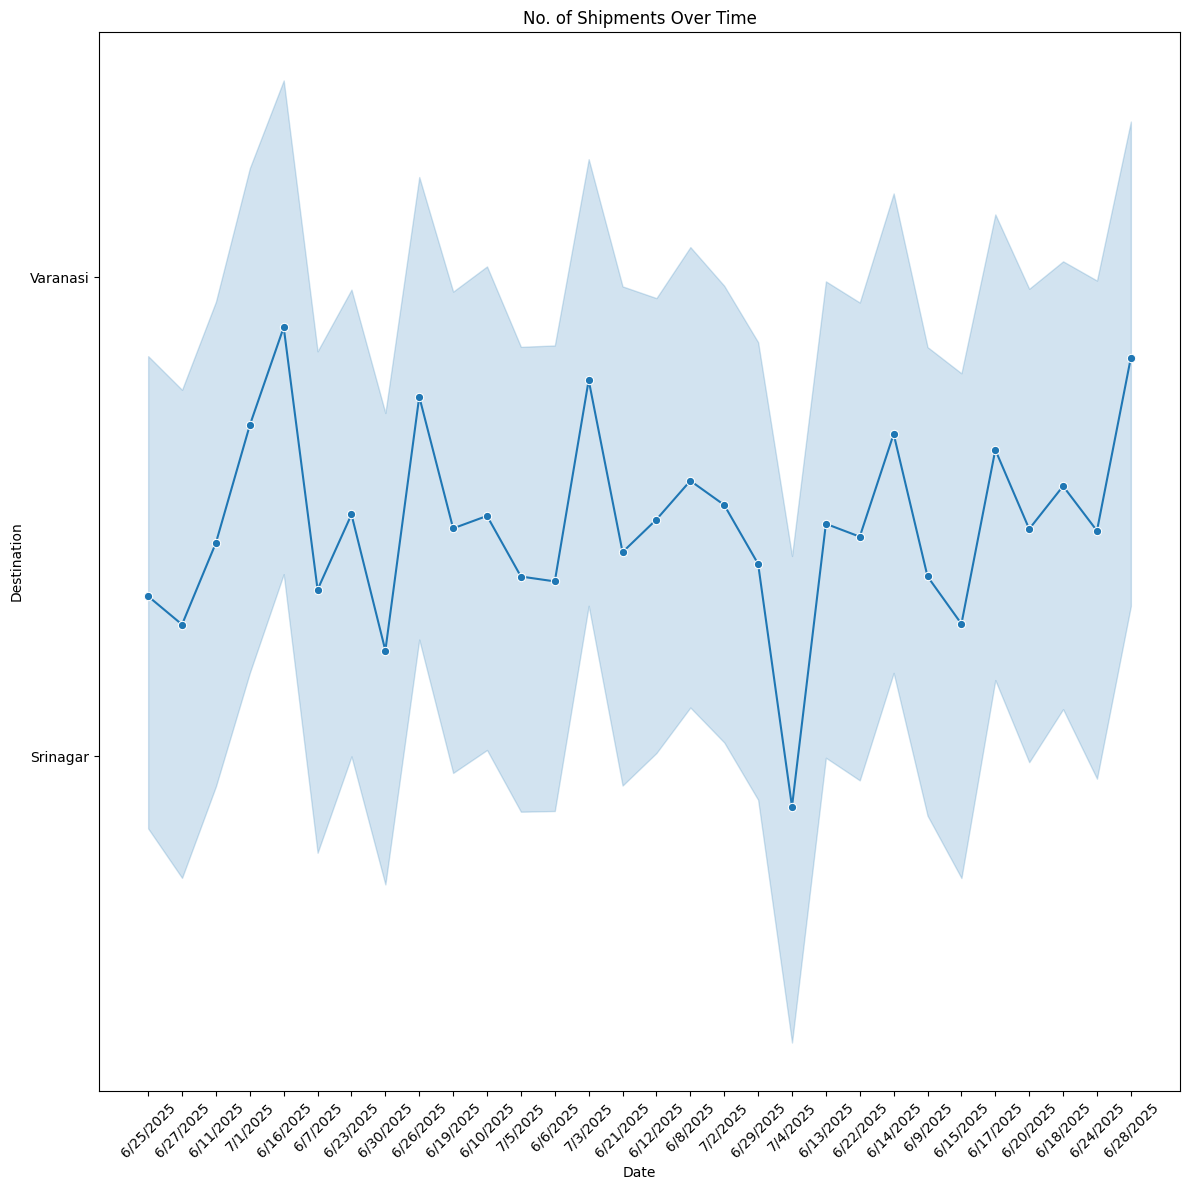

In [11]:
# plot line graph for 'No. of Shipments' over 'Date'
plt.figure(figsize=(12, 12))
sns.lineplot(data=df, x='Date', y='Destination', marker='o')
plt.title('No. of Shipments Over Time')
plt.xlabel('Date')
plt.ylabel('Destination')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



/var/folders/_w/37j664rn70x1hptwtp860dl80000gn/T/ipykernel_11245/3146995835.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Origin', y='Destination', ci=None)


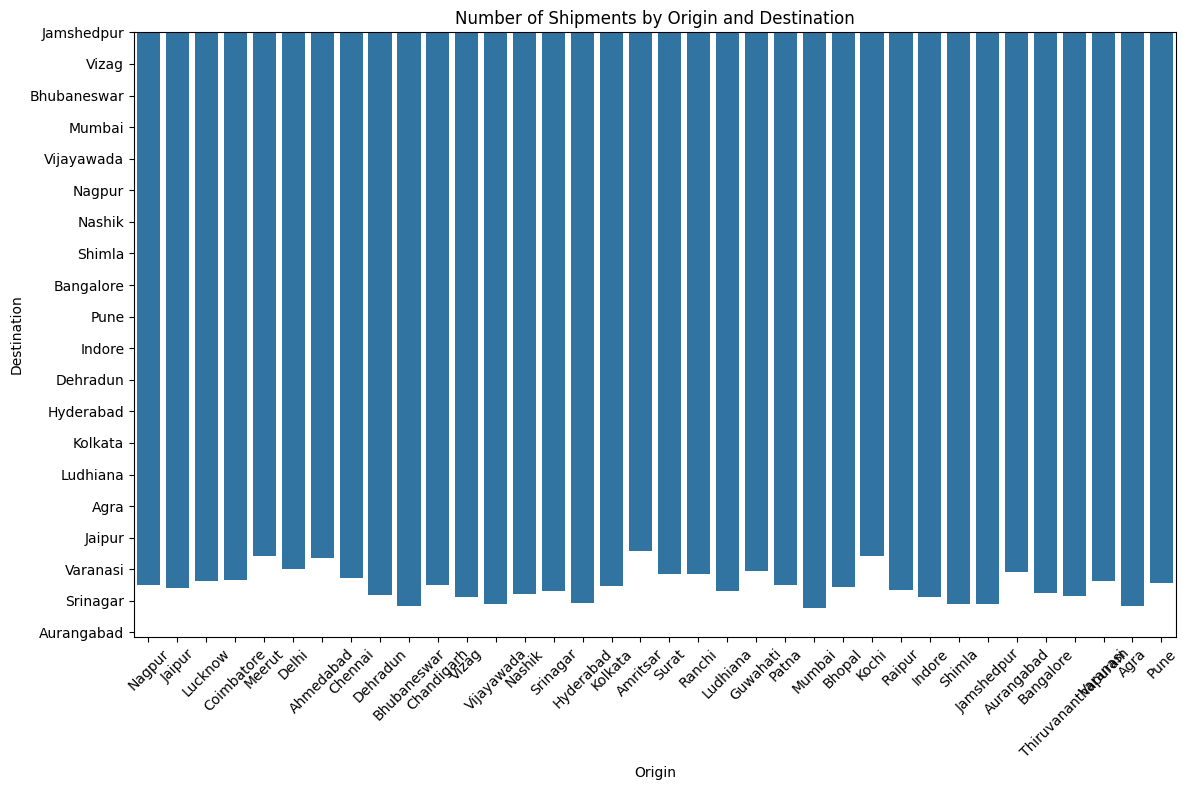

In [12]:
# plot bar graph for 'Destination' by 'Origin'
plt.figure(figsize=(12, 8)) 
sns.barplot(data=df, x='Origin', y='Destination', ci=None)
plt.title('Number of Shipments by Origin and Destination')
plt.xlabel('Origin')
plt.ylabel('Destination')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


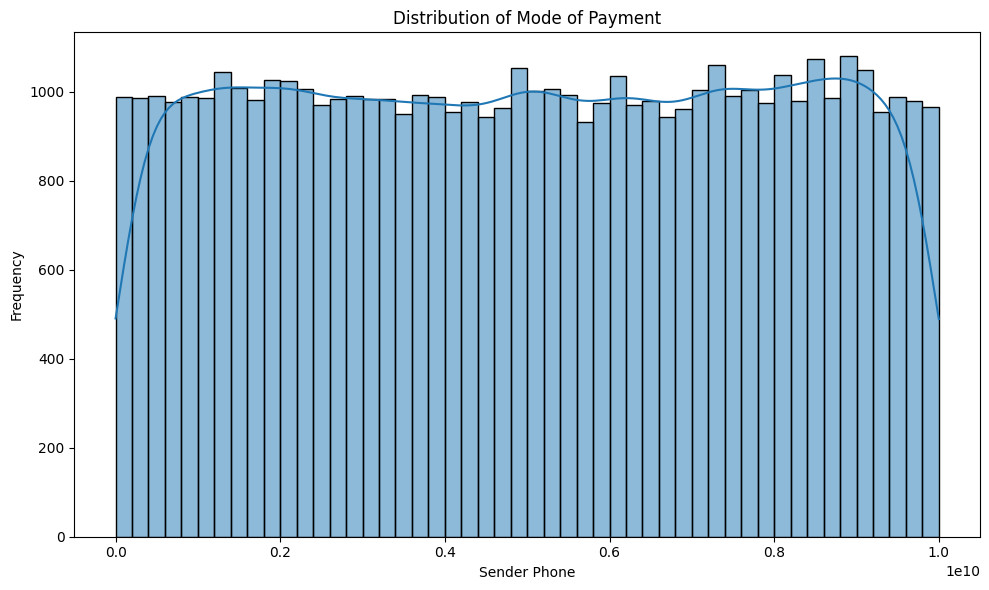

In [13]:
# plot histogram for 'Mode of payment'
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Sender Phone', bins=50, kde=True)
plt.title('Distribution of Mode of Payment')
plt.xlabel('Sender Phone')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


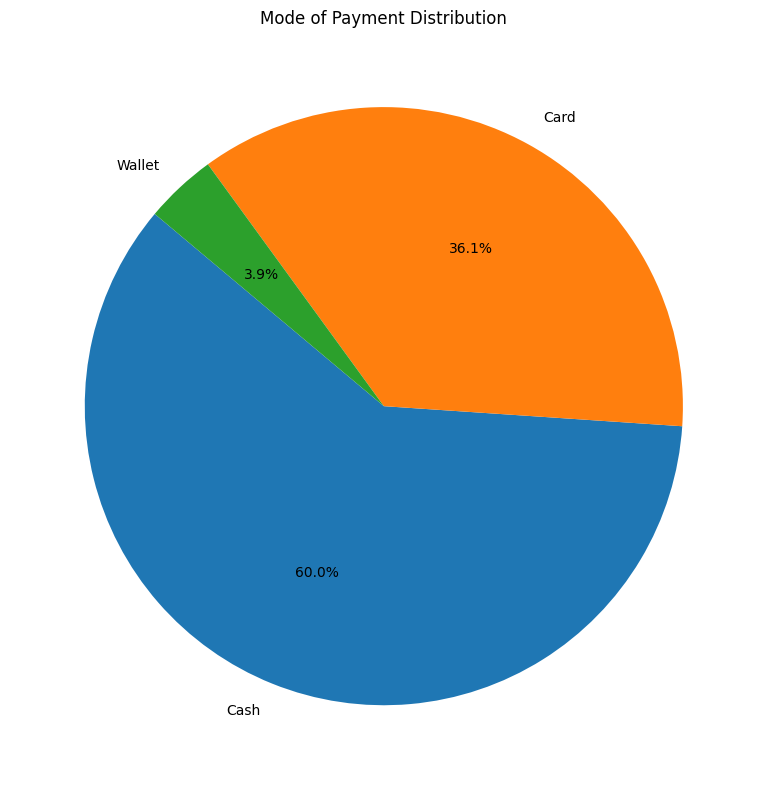

In [14]:
# PieChart for 'Mode of payment'

plt.figure(figsize=(8, 8))
mode_counts = df['Mode of Payment'].value_counts()
plt.pie(mode_counts, labels=mode_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Mode of Payment Distribution')
plt.tight_layout()
plt.show()


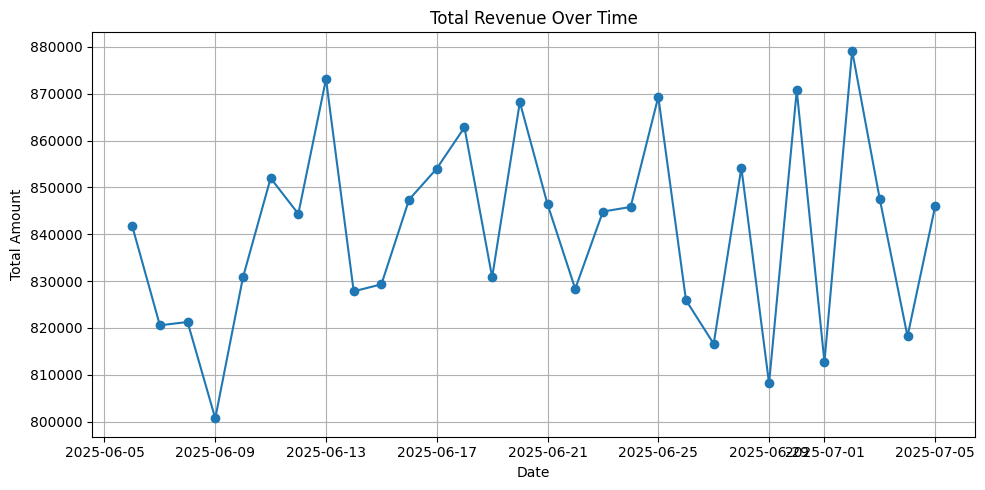

In [15]:
##  Line Graph
# # Convert Date column to datetime format, Shows revenue fluctuations over time.
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Group data by Date and calculate total revenue
daily_revenue = df.groupby('Date')['Total Amount'].sum()

# Plot line graph
plt.figure(figsize=(10,5))
plt.plot(daily_revenue.index, daily_revenue.values, marker='o')

plt.title("Total Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Total Amount")
plt.grid(True)
plt.tight_layout()
plt.show()


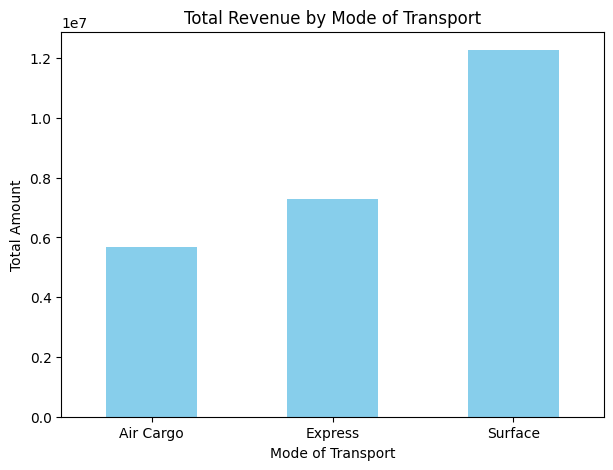

In [16]:

# Group data by Mode, Compares which transport mode earns more revenue.
mode_revenue = df.groupby('Mode')['Total Amount'].sum()

# Plot bar chart
plt.figure(figsize=(7,5))
mode_revenue.plot(kind='bar', color='skyblue')

plt.title("Total Revenue by Mode of Transport")
plt.xlabel("Mode of Transport")
plt.ylabel("Total Amount")
plt.xticks(rotation=0)

plt.show()


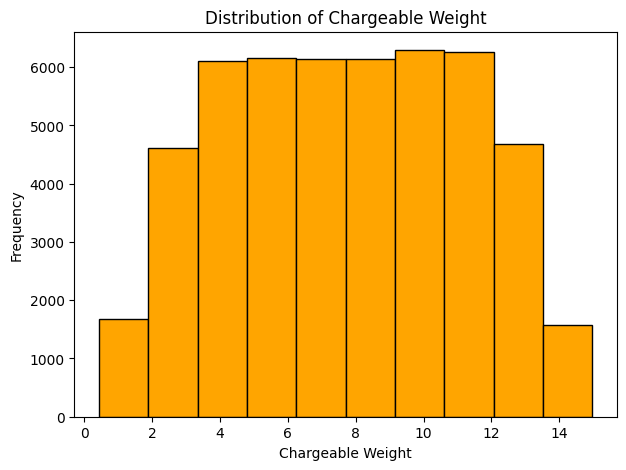

In [17]:

# Plot histogram for Chargeable Weight, Shows common weight ranges of consignments.
plt.figure(figsize=(7,5))
plt.hist(df['Chargeable Wt'], bins=10, color='orange', edgecolor='black')

plt.title("Distribution of Chargeable Weight")
plt.xlabel("Chargeable Weight")
plt.ylabel("Frequency")

plt.show()


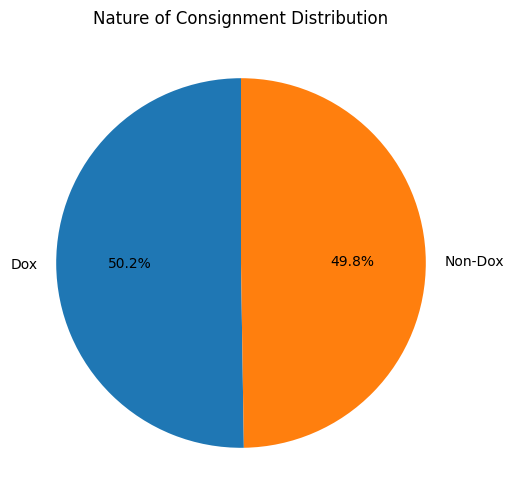

In [18]:

# Count nature of consignments, Shows percentage share of Dox and Non‑Dox shipments.
consignment_count = df['Nature of Consignment'].value_counts()

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(consignment_count,
        labels=consignment_count.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Nature of Consignment Distribution")
plt.show()


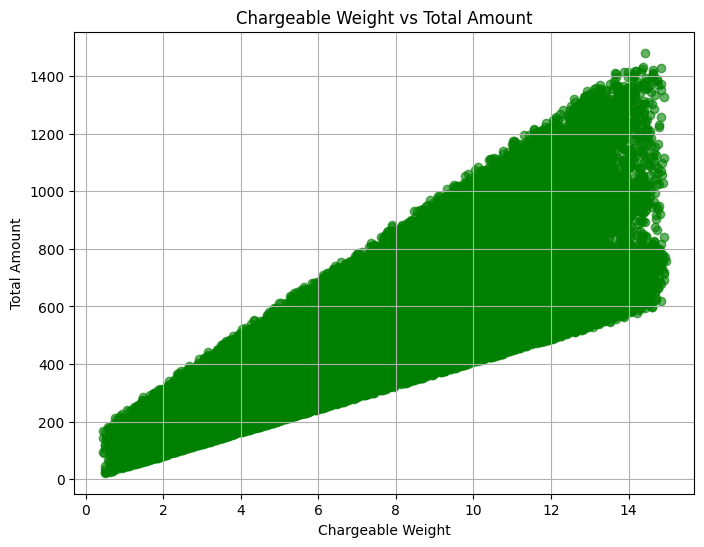

In [19]:
# Scatter plot to show relationship between Chargeable Weight and Total Amount.

plt.figure(figsize=(8,6))
plt.scatter(df['Chargeable Wt'], df['Total Amount'], alpha=0.6, color='green')
plt.title("Chargeable Weight vs Total Amount")
plt.xlabel("Chargeable Weight")
plt.ylabel("Total Amount")
plt.grid(True)
plt.show()


In [20]:
df.describe()

,Date,Sender Phone,Sender Pincode,Sender GSTIN,Total Pieces,Actual Wt,Volumetric Wt,Chargeable Wt,Sender Signature,Recipient Phone,Receiver Pincode,Tariff,VAS Charges,Total Amount
count,49639,4.963900e+04,49639.000000,49639.0,49639.000000,49639.000000,49639.000000,49639.000000,49639.0,4.963900e+04,49639.000000,49639.000000,49639.000000,49639.000000
mean,2025-06-20 12:24:00.319104,5.010054e+09,499786.484055,0.0,2.994480,6.167263,7.716568,7.716568,0.0,4.973767e+09,500547.941115,440.854079,67.198937,508.053016
min,2025-06-06 00:00:00,1.710800e+04,1.000000,0.0,1.000000,0.300000,0.440000,0.440000,0.0,2.289200e+05,2.000000,19.900000,0.000000,22.630000
25%,2025-06-13 00:00:00,2.479984e+09,248197.500000,0.0,2.000000,3.260000,4.800000,4.800000,0.0,2.473943e+09,252065.000000,255.040000,27.305000,320.395000
50%,2025-06-21 00:00:00,5.018929e+09,499479.000000,0.0,3.000000,6.190000,7.740000,7.740000,0.0,4.960678e+09,502320.000000,409.980000,67.450000,477.640000
75%,2025-06-28 00:00:00,7.533459e+09,748322.000000,0.0,4.000000,9.080000,10.640000,10.640000,0.0,7.459426e+09,749229.500000,571.570000,108.860000,644.805000
max,2025-07-05 00:00:00,9.999872e+09,999981.000000,0.0,5.000000,12.000000,14.970000,14.970000,0.0,9.999958e+09,999973.000000,1372.900000,150.000000,1481.160000
std,NaN,2.892645e+09,288607.647965,0.0,1.415086,3.375089,3.476748,3.476748,0.0,2.883664e+09,287851.384963,243.188225,47.899430,248.097236
